# 01 — Policy Evaluation
**Week 4 | Dynamic Programming**

**Policy Evaluation** answers: *How good is a given policy π?*

We iteratively apply the Bellman expectation equation until V converges:

$$V_{k+1}(s) = \sum_a \pi(a|s) \sum_{s'} P(s'|s,a) \left[ R(s,a,s') + \gamma V_k(s') \right]$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

# ---- Reuse Grid World from Week 3 ----
class GridWorld:
    ACTIONS = {0:(-1,0), 1:(1,0), 2:(0,-1), 3:(0,1)}
    ACTION_SYMBOLS = {0:'↑', 1:'↓', 2:'←', 3:'→'}
    def __init__(self, size=5):
        self.size = size; self.start=(0,0); self.goal=(size-1,size-1)
        self.pits = {(1,1),(1,3),(3,1),(3,3)}
    def n_states(self): return self.size**2
    def n_actions(self): return 4
    def transitions(self, s, a):
        """Return list of (prob, next_s, reward, done)."""
        r, c = divmod(s, self.size)
        dr, dc = self.ACTIONS[a]
        nr = max(0, min(self.size-1, r+dr)); nc = max(0, min(self.size-1, c+dc))
        ns = nr*self.size + nc
        if (nr,nc) == self.goal:       return [(1.0, ns, +10.0, True)]
        if (nr,nc) in self.pits:       return [(1.0, ns,  -5.0, True)]
        return [(1.0, ns, -0.1, False)]

env = GridWorld()

In [2]:
def policy_evaluation(env, policy, gamma=0.99, theta=1e-6, max_iter=1000):
    """
    Iterative policy evaluation.
    policy: array of shape (n_states, n_actions) — action probabilities.
    Returns V: array of shape (n_states,)
    """
    V = np.zeros(env.n_states())
    history = [V.copy()]
    for iteration in range(max_iter):
        delta = 0.0
        V_new = np.zeros_like(V)
        for s in range(env.n_states()):
            v = 0.0
            for a in range(env.n_actions()):
                for prob, ns, reward, done in env.transitions(s, a):
                    v += policy[s, a] * prob * (reward + (0 if done else gamma * V[s]))
            V_new[s] = v
            delta = max(delta, abs(V_new[s] - V[s]))
        V = V_new
        history.append(V.copy())
        if delta < theta:
            print(f"Converged in {iteration+1} iterations (Δ={delta:.2e})")
            break
    return V, history

In [3]:
# Uniform random policy
n_s, n_a = env.n_states(), env.n_actions()
uniform_policy = np.ones((n_s, n_a)) / n_a

V, history = policy_evaluation(env, uniform_policy)

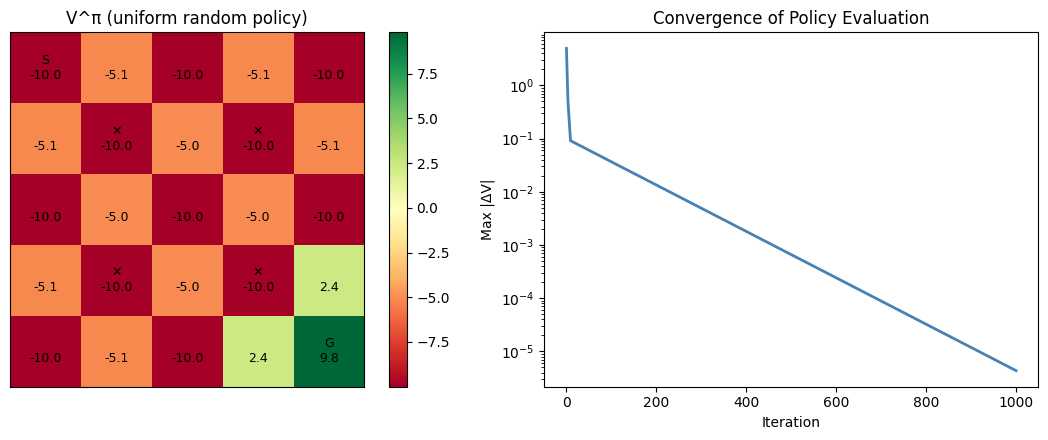

In [4]:
# Visualise final value function
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Heatmap
im = axes[0].imshow(V.reshape(5,5), cmap='RdYlGn')
plt.colorbar(im, ax=axes[0])
for r in range(5):
    for c in range(5):
        label = ''
        if (r,c)==env.goal: label='G'
        elif (r,c)==env.start: label='S'
        elif (r,c) in env.pits: label='✕'
        axes[0].text(c, r, f'{label}\n{V[r*5+c]:.1f}', ha='center', va='center', fontsize=9)
axes[0].set_title('V^π (uniform random policy)'); axes[0].set_xticks([]); axes[0].set_yticks([])

# Convergence curve
max_delta = [np.max(np.abs(history[i+1]-history[i])) for i in range(len(history)-1)]
axes[1].semilogy(max_delta, color='steelblue', linewidth=2)
axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('Max |ΔV|')
axes[1].set_title('Convergence of Policy Evaluation')
plt.tight_layout(); plt.show()

## ✅ Exercises
1. Try γ=0.5, γ=0.9, γ=0.999. How does the value function shape change?
2. Create a policy that always moves RIGHT. Evaluate it. What happens to states on the rightmost column?
3. **Challenge**: implement **in-place** policy evaluation (update V[s] immediately instead of V_new). Does it converge faster?

# Answer

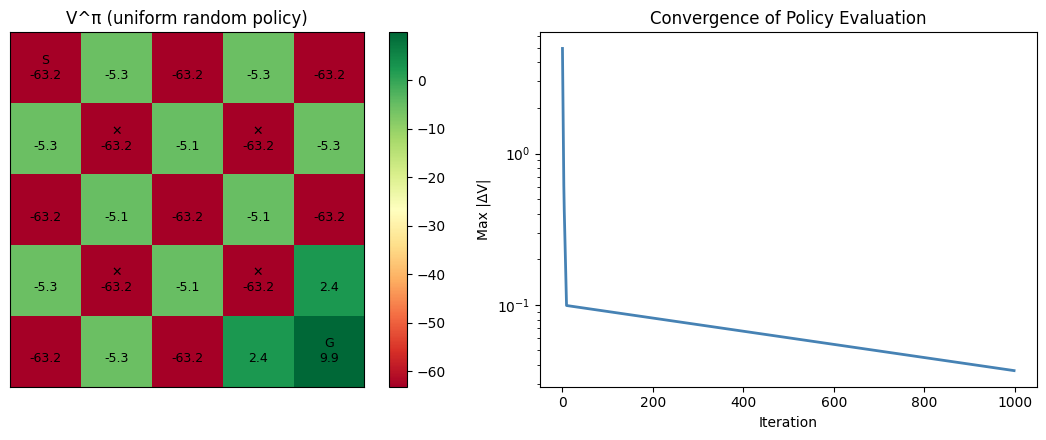

In [14]:

V, history = policy_evaluation(env, uniform_policy,0.999)
# Visualise final value function
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Heatmap
im = axes[0].imshow(V.reshape(5,5), cmap='RdYlGn')
plt.colorbar(im, ax=axes[0])
for r in range(5):
    for c in range(5):
        label = ''
        if (r,c)==env.goal: label='G'
        elif (r,c)==env.start: label='S'
        elif (r,c) in env.pits: label='✕'
        axes[0].text(c, r, f'{label}\n{V[r*5+c]:.1f}', ha='center', va='center', fontsize=9)
axes[0].set_title('V^π (uniform random policy)'); axes[0].set_xticks([]); axes[0].set_yticks([])

# Convergence curve
max_delta = [np.max(np.abs(history[i+1]-history[i])) for i in range(len(history)-1)]
axes[1].semilogy(max_delta, color='steelblue', linewidth=2)
axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('Max |ΔV|')
axes[1].set_title('Convergence of Policy Evaluation')
plt.tight_layout(); plt.show()

The convergence happens fast in the less iterations with less gamma value
the value function runs for the longer iterations 

In [15]:
import numpy as np

class GridWorld:
    """
    A simple 5x5 Grid World environment.
    """
    def __init__(self, size=5):
        self.size = size
        self.terminal_state = (size - 1, size - 1)
        self.states = [(r, c) for r in range(size) for c in range(size)]

    def step(self, state, action):
        """
        Calculates the next state and reward for a given state and action.
        """
        if state == self.terminal_state:
            return state, 0 # No reward, no movement from terminal state

        row, col = state
        if action == 'UP':
            row = max(0, row - 1)
        elif action == 'DOWN':
            row = min(self.size - 1, row + 1)
        elif action == 'LEFT':
            col = max(0, col - 1)
        elif action == 'RIGHT':
            col = min(self.size - 1, col + 1)
        
        next_state = (row, col)
        reward = -1
        return next_state, reward

def policy_evaluation(grid, policy, gamma=0.9, theta=1e-6):
    """
    Performs iterative policy evaluation.

    Args:
        grid: The GridWorld environment.
        policy: A dictionary mapping state -> action.
        gamma: Discount factor.
        theta: A small threshold for determining convergence.

    Returns:
        The value function V(s) for the given policy.
    """
    # 1. Initialize V(s) = 0 for all states
    V = np.zeros((grid.size, grid.size))
    
    while True:
        delta = 0
        # 2. Loop over all states
        for state in grid.states:
            if state == grid.terminal_state:
                continue

            v_old = V[state]
            
            # Get the action from the policy
            action = policy[state]
            
            # Get the next state and reward from the environment
            next_state, reward = grid.step(state, action)
            
            # 3. Apply the Bellman update
            V[state] = reward + gamma * V[next_state]
            
            delta = max(delta, abs(v_old - V[state]))
        
        # 4. Check for convergence
        if delta < theta:
            break
            
    return V

# --- Main Execution ---

# 1. Create the environment
grid = GridWorld(size=5)

# 2. Create the policy: always move RIGHT
policy_right = {state: 'RIGHT' for state in grid.states}

# 3. Evaluate the policy
print("Evaluating the 'always RIGHT' policy...")
value_function = policy_evaluation(grid, policy_right)

# 4. Print the results
print("\nValue Function V(s) for the 'always RIGHT' policy:")
print(np.round(value_function, decimals=1))



Evaluating the 'always RIGHT' policy...

Value Function V(s) for the 'always RIGHT' policy:
[[-10.  -10.  -10.  -10.  -10. ]
 [-10.  -10.  -10.  -10.  -10. ]
 [-10.  -10.  -10.  -10.  -10. ]
 [-10.  -10.  -10.  -10.  -10. ]
 [ -3.4  -2.7  -1.9  -1.    0. ]]


In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

# ---- Reuse Grid World from Week 3 ----
class GridWorld:
    ACTIONS = {0:(-1,0), 1:(1,0), 2:(0,-1), 3:(0,1)}
    ACTION_SYMBOLS = {0:'↑', 1:'↓', 2:'←', 3:'→'}
    def __init__(self, size=5):
        self.size = size; self.start=(0,0); self.goal=(size-1,size-1)
        self.pits = {(1,1),(1,3),(3,1),(3,3)}
    def n_states(self): return self.size**2
    def n_actions(self): return 4
    def transitions(self, s, a):
        """Return list of (prob, next_s, reward, done)."""
        r, c = divmod(s, self.size)
        dr, dc = self.ACTIONS[a]
        nr = max(0, min(self.size-1, r+dr)); nc = max(0, min(self.size-1, c+dc))
        ns = nr*self.size + nc
        if (nr,nc) == self.goal:       return [(1.0, ns, +10.0, True)]
        if (nr,nc) in self.pits:       return [(1.0, ns,  -5.0, True)]
        return [(1.0, ns, -0.1, False)]

env = GridWorld()

In [2]:
def policy_evaluation(env, policy, gamma=0.99, theta=1e-6, max_iter=1000):
    """
    Iterative policy evaluation.
    policy: array of shape (n_states, n_actions) — action probabilities.
    Returns V: array of shape (n_states,)
    """
    V = np.zeros(env.n_states())
    history = [V.copy()]
    for iteration in range(max_iter):
        delta = 0.0
        V_new = np.zeros_like(V)
        for s in range(env.n_states()):
            v = 0.0
            for a in range(env.n_actions()):
                for prob, ns, reward, done in env.transitions(s, a):
                    v += policy[s, a] * prob * (reward + (0 if done else gamma * V[s]))
            V[s] = v
            delta = max(delta, abs(V_new[s] - V[s]))
        history.append(V.copy())
        if delta < theta:
            print(f"Converged in {iteration+1} iterations (Δ={delta:.2e})")
            break
    return V, history

In [3]:
# Uniform random policy
n_s, n_a = env.n_states(), env.n_actions()
uniform_policy = np.ones((n_s, n_a)) / n_a

V, history = policy_evaluation(env, uniform_policy)

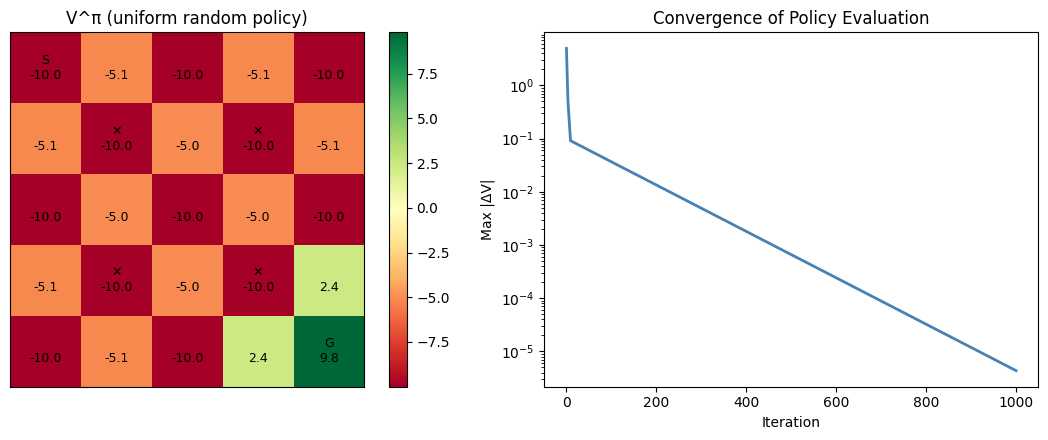

In [4]:
# Visualise final value function
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Heatmap
im = axes[0].imshow(V.reshape(5,5), cmap='RdYlGn')
plt.colorbar(im, ax=axes[0])
for r in range(5):
    for c in range(5):
        label = ''
        if (r,c)==env.goal: label='G'
        elif (r,c)==env.start: label='S'
        elif (r,c) in env.pits: label='✕'
        axes[0].text(c, r, f'{label}\n{V[r*5+c]:.1f}', ha='center', va='center', fontsize=9)
axes[0].set_title('V^π (uniform random policy)'); axes[0].set_xticks([]); axes[0].set_yticks([])

# Convergence curve
max_delta = [np.max(np.abs(history[i+1]-history[i])) for i in range(len(history)-1)]
axes[1].semilogy(max_delta, color='steelblue', linewidth=2)
axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('Max |ΔV|')
axes[1].set_title('Convergence of Policy Evaluation')
plt.tight_layout(); plt.show()

It doesn.t depend on the replacement in new or the diect